# Trabajo Final: Algoritmos 
**Caso:** DataExpert · **Dataset:** Seeds (7 características + Class)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

## 1. Cargar y explorar el dataset

In [2]:
# Cambia la ruta si tu archivo está en otro lugar (en Colab: súbelo y usa su nombre)
RUTA = 'data/seeds.csv'
df = pd.read_csv(RUTA)
# Si tu archivo trae otros nombres de columna, se estandarizan (mismo orden)
df.columns = ['Area','Perimeter','Compactness','Length','Width','Asymmetry','Groove','Class']
df.head()

,Area,Perimeter,Compactness,Length,Width,Asymmetry,Groove,Class
0,13.95,14.10,0.8827,5.550,3.341,1.553,4.875,1
1,14.63,14.62,0.8623,5.629,3.206,2.750,5.267,1
2,13.82,13.94,0.8918,5.297,3.180,1.765,4.975,1
3,15.18,14.64,0.8820,5.658,3.307,4.200,5.253,1
4,13.95,13.89,0.9032,5.314,3.418,3.274,4.644,1


In [3]:
print(df.shape)
df.info()

(210, 8)
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         210 non-null    float64
 1   Perimeter    210 non-null    float64
 2   Compactness  210 non-null    float64
 3   Length       210 non-null    float64
 4   Width        210 non-null    float64
 5   Asymmetry    210 non-null    float64
 6   Groove       210 non-null    float64
 7   Class        210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [4]:
# Verificar valores nulos
print(df.isnull().sum())
print('Total de nulos:', df.isnull().sum().sum())

Area           0
Perimeter      0
Compactness    0
Length         0
Width          0
Asymmetry      0
Groove         0
Class          0
dtype: int64
Total de nulos: 0


In [5]:
caracteristicas = df.columns.drop('Class')
print('Características (', len(caracteristicas), '):', list(caracteristicas))
df['Class'].value_counts().sort_index()

Características ( 7 ): ['Area', 'Perimeter', 'Compactness', 'Length', 'Width', 'Asymmetry', 'Groove']


Class
1    70
2    70
3    70
Name: count, dtype: int64

## 2. Separar X / y y normalizar con StandardScaler

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
print('Medias (≈0):'); print(X_norm.mean().round(6))
print('Desv. estándar (≈1):'); print(X_norm.std(ddof=0).round(6))

Medias (≈0):
Area          -0.0
Perimeter      0.0
Compactness   -0.0
Length         0.0
Width         -0.0
Asymmetry      0.0
Groove        -0.0
dtype: float64
Desv. estándar (≈1):
Area           1.0
Perimeter      1.0
Compactness    1.0
Length         1.0
Width          1.0
Asymmetry      1.0
Groove         1.0
dtype: float64


## 3. Álgebra lineal con NumPy

In [7]:
# Vectores: dos observaciones del dataset
v1 = X.iloc[0].to_numpy()
v2 = X.iloc[1].to_numpy()
print('v1 =', v1); print('v2 =', v2)

v1 = [13.95   14.1     0.8827  5.55    3.341   1.553   4.875 ]
v2 = [14.63   14.62    0.8623  5.629   3.206   2.75    5.267 ]


In [8]:
print('Producto punto:', np.dot(v1, v2))
print('Norma v1:', np.linalg.norm(v1))
print('Norma v2:', np.linalg.norm(v2))
print('Similitud coseno:', np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

Producto punto: 482.89122321
Norma v1: 21.501950476410272
Norma v2: 22.489836088553425
Similitud coseno: 0.9985852905855049


In [9]:
# Matrices
M = X.iloc[:3, :3].to_numpy()
print('M =\n', M)
print('Transpuesta =\n', M.T)
print('M @ M.T =\n', M @ M.T)
print('Determinante:', np.linalg.det(M))

M =
 [[13.95   14.1     0.8827]
 [14.63   14.62    0.8623]
 [13.82   13.94    0.8918]]
Transpuesta =
 [[13.95   14.63   13.82  ]
 [14.1    14.62   13.94  ]
 [ 0.8827  0.8623  0.8918]]
M @ M.T =
 [[394.19165929 410.99165221 390.13019186]
 [410.99165221 428.52486129 406.75839914]
 [390.13019186 406.75839914 386.11130724]]
Determinante: -0.06574624000000225


In [10]:
# Sistema de ecuaciones  A·x = b
#  2x +  y -  z =  8
# -3x -  y + 2z = -11
# -2x +  y + 2z = -3
A = np.array([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]])
b = np.array([8, -11, -3])
sol = np.linalg.solve(A, b)
print('x, y, z =', sol)
print('¿A·x = b?', np.allclose(A @ sol, b))

x, y, z = [ 2.  3. -1.]
¿A·x = b? True


## 4. Medidas estadísticas de Area y Perimeter

In [11]:
for col in ['Area', 'Perimeter']:
    print('---', col, '---')
    print('Media   :', df[col].mean())
    print('Mediana :', df[col].median())
    print('Varianza:', np.var(df[col], ddof=1))
    print('Desv.est:', np.std(df[col], ddof=1))

--- Area ---
Media   : 14.827619047619049
Mediana : 14.254999999999999
Varianza: 8.565139758487128
Desv.est: 2.926626002496241
--- Perimeter ---
Media   : 14.555142857142856
Mediana : 14.23
Varianza: 1.7078365823650032
Desv.est: 1.3068422178537864


In [12]:
# Implementación manual (ddof=1: varianza muestral, igual que Pandas)
def varianza(datos, ddof=1):
    datos = list(datos)
    n = len(datos)
    media = sum(datos) / n
    return sum((x - media) ** 2 for x in datos) / (n - ddof)

def desviacion(datos, ddof=1):
    return varianza(datos, ddof) ** 0.5

area = df['Area']
print('Varianza manual :', varianza(area), '| NumPy:', np.var(area, ddof=1))
print('Desv. manual    :', desviacion(area), '| NumPy:', np.std(area, ddof=1))
print('¿Coinciden?', np.isclose(varianza(area), np.var(area, ddof=1)),
      np.isclose(desviacion(area), np.std(area, ddof=1)))
# Nota: np.var por defecto usa ddof=0 (poblacional); con ddof=1 coincide con Pandas.

Varianza manual : 8.565139758487128 | NumPy: 8.565139758487128
Desv. manual    : 2.926626002496241 | NumPy: 2.926626002496241
¿Coinciden? True True


## 5. Valores atípicos en Area (criterio de 2 desviaciones estándar)

In [13]:
media = area.mean()
sigma = area.std()
lim_inf, lim_sup = media - 2 * sigma, media + 2 * sigma
print(f'Intervalo normal: [{lim_inf:.3f}, {lim_sup:.3f}]')

atipicos = df[(df['Area'] < lim_inf) | (df['Area'] > lim_sup)]
print('Cantidad de atípicos:', len(atipicos), 'de', len(df))
atipicos[['Area', 'Perimeter', 'Class']]

Intervalo normal: [8.974, 20.681]
Cantidad de atípicos: 5 de 210


,Area,Perimeter,Class
72,22.70,17.80,2
95,20.85,17.00,2
99,21.64,17.31,2
125,21.14,17.34,2
127,20.77,17.18,2


## 6. Gráficos

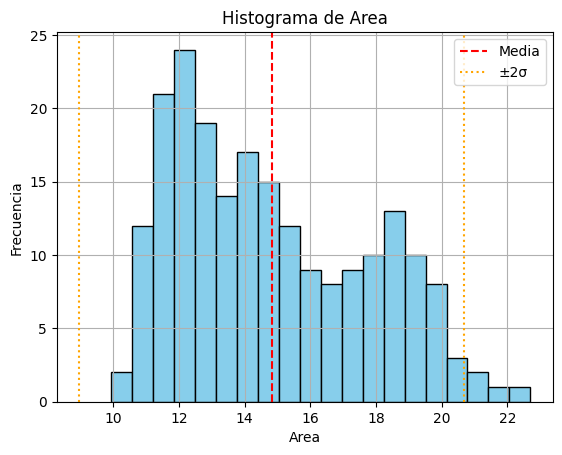

In [14]:
# Histograma de Area
plt.hist(df['Area'], bins=20, edgecolor='black', color='skyblue')
plt.axvline(media, color='r', linestyle='--', label='Media')
plt.axvline(lim_inf, color='orange', linestyle=':', label='±2σ')
plt.axvline(lim_sup, color='orange', linestyle=':')
plt.title('Histograma de Area')
plt.xlabel('Area')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid()
plt.show()

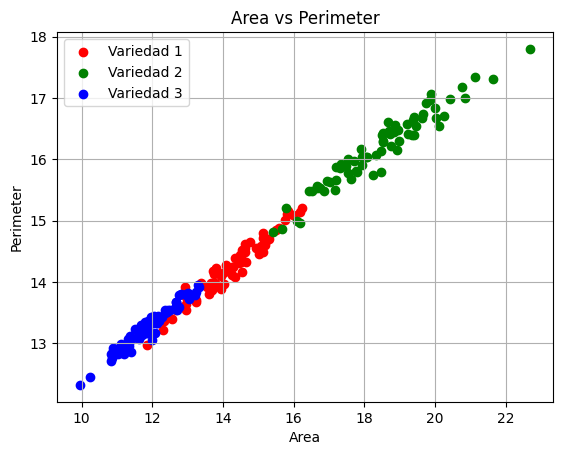

In [15]:
# Dispersión Area vs Perimeter por variedad
colores = {1: 'r', 2: 'g', 3: 'b'}
for clase in sorted(df['Class'].unique()):
    sub = df[df['Class'] == clase]
    plt.scatter(sub['Area'], sub['Perimeter'], color=colores[clase], label=f'Variedad {clase}')
plt.title('Area vs Perimeter')
plt.xlabel('Area')
plt.ylabel('Perimeter')
plt.legend()
plt.grid()
plt.show()

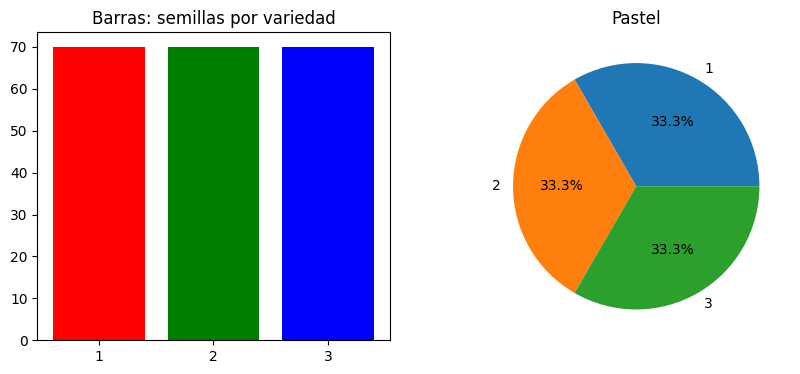

In [16]:
# Reporte por variedad con groupby (como en clase): barras + pastel
conteo_por_clase = df.groupby('Class')['Area'].count()
cat = conteo_por_clase.index.astype(str)
val = conteo_por_clase.values
col = ['r', 'g', 'b']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(cat, val, color=col)
axes[0].set_title('Barras: semillas por variedad')
axes[1].pie(val, labels=cat, autopct='%1.1f%%')
axes[1].set_title('Pastel')
plt.show()

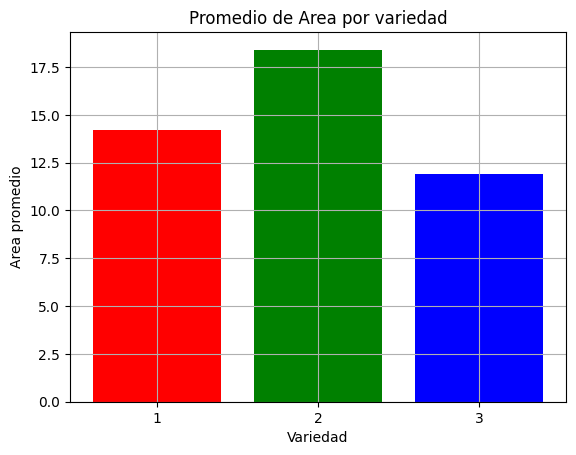

In [17]:
# Promedio de Area por variedad
promedio_area = df.groupby('Class')['Area'].mean()
plt.bar(promedio_area.index.astype(str), promedio_area.values, color=col)
plt.title('Promedio de Area por variedad')
plt.xlabel('Variedad')
plt.ylabel('Area promedio')
plt.grid()
plt.show()

## 7. Clasificación: K-Vecinos vs Árbol de Decisión

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# El scaler se ajusta solo con entrenamiento (evita fuga de datos)
sc = StandardScaler().fit(X_train)
X_train_n, X_test_n = sc.transform(X_train), sc.transform(X_test)

In [19]:
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_n, y_train)
arbol = DecisionTreeClassifier(random_state=42).fit(X_train_n, y_train)

acc_knn = accuracy_score(y_test, knn.predict(X_test_n))
acc_arbol = accuracy_score(y_test, arbol.predict(X_test_n))
print('Accuracy KNN   :', round(acc_knn, 4))
print('Accuracy Árbol :', round(acc_arbol, 4))

Accuracy KNN   : 0.9434
Accuracy Árbol : 0.9057


Matriz de confusión KNN:
 [[15  1  1]
 [ 1 17  0]
 [ 0  0 18]]
Matriz de confusión Árbol:
 [[15  1  1]
 [ 1 17  0]
 [ 2  0 16]]


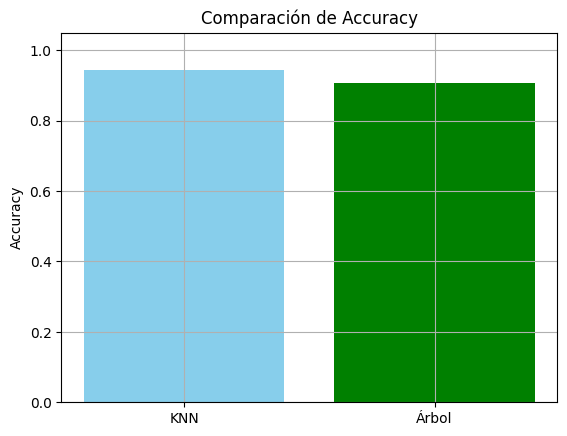

In [20]:
print('Matriz de confusión KNN:\n', confusion_matrix(y_test, knn.predict(X_test_n)))
print('Matriz de confusión Árbol:\n', confusion_matrix(y_test, arbol.predict(X_test_n)))

plt.bar(['KNN', 'Árbol'], [acc_knn, acc_arbol], color=['skyblue', 'g'])
plt.ylim(0, 1.05)
plt.title('Comparación de Accuracy')
plt.ylabel('Accuracy')
plt.grid()
plt.show()